<a href="https://www.kaggle.com/code/izzarsulynashrudin/classificationnihchestxrays?scriptVersionId=304215449" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Overview


This project uses the **NIH Chest X-Rays Dataset** for thoracic disease classification and disease object detection in chest X-ray images. The dataset contains **112,120 images**, making it highly suitable for *deep learning*-based research in multi-label classification and object detection tasks.

## Methods Used


| Method | Task                      | Primary Metric   |
| ------ | -------------------------- | ---------------- |
| CNN    | Multi-label classification | PR-AUC / ROC-AUC |
| ResNet | Multi-label classification | PR-AUC / ROC-AUC |
| YOLO   | Object detection           | mAP@0.5          |

## Dataset Download Links

[Official Site](https://nihcc.app.box.com/v/ChestXray-NIHCC) 
or 
[Kaggle Dataset](https://www.kaggle.com/datasets/nih-chest-xrays/data)

## Why Use Kaggle

Kaggle is used to support the model training process because the dataset is quite large, containing **112,120 images**, and therefore requires GPU acceleration to improve model performance. In addition, training and evaluation take a considerable amount of time, so Kaggle is one of the platforms that supports these computational needs.

Therefore, I would like to thank everyone who has supported this research.

**Izzar Suly Nashrudin**


# Package Installation

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from tensorflow import keras
from tensorflow.keras import layers

E0000 00:00:1773735307.259042      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773735307.410805      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773735308.611016      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773735308.611066      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773735308.611069      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773735308.611072      23 computation_placer.cc:177] computation placer already registered. Please check linka

# Preprocessing

## Set Path Dataset

In [2]:
datasetPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
bboxPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv"

print(os.listdir(datasetPath)[:20])

['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


## Load and Clean Label Data

In [3]:
labelDf = pd.read_csv(os.path.join(datasetPath, "Data_Entry_2017.csv"))

labelDf = labelDf.loc[:, ~labelDf.columns.str.contains("^Unnamed")]

labelDf = labelDf.rename(columns={
    "Image Index": "imageIndex",
    "Finding Labels": "findingLabels",
    "Follow-up #": "followUpNumber",
    "Patient ID": "patientId",
    "Patient Age": "patientAge",
    "Patient Gender": "patientGender",
    "View Position": "viewPosition",
    "OriginalImage[Width": "originalImageWidth",
    "Height]": "originalImageHeight",
    "OriginalImagePixelSpacing[x": "originalImagePixelSpacingX",
    "y]": "originalImagePixelSpacingY"
})

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,originalImagePixelSpacingY
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


## Standardize Data Types

In [4]:
numericColumns = [
    "followUpNumber",
    "patientId",
    "patientAge",
    "originalImageWidth",
    "originalImageHeight",
    "originalImagePixelSpacingX",
    "originalImagePixelSpacingY"
]

for columnName in numericColumns:
    labelDf[columnName] = pd.to_numeric(labelDf[columnName], errors="coerce")

labelDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   imageIndex                  112120 non-null  object 
 1   findingLabels               112120 non-null  object 
 2   followUpNumber              112120 non-null  int64  
 3   patientId                   112120 non-null  int64  
 4   patientAge                  112120 non-null  int64  
 5   patientGender               112120 non-null  object 
 6   viewPosition                112120 non-null  object 
 7   originalImageWidth          112120 non-null  int64  
 8   originalImageHeight         112120 non-null  int64  
 9   originalImagePixelSpacingX  112120 non-null  float64
 10  originalImagePixelSpacingY  112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


## Create Label List and Target Labels

In [5]:
labelDf["labelList"] = labelDf["findingLabels"].str.split("|")

allLabels = sorted({
    labelName
    for labelList in labelDf["labelList"]
    for labelName in labelList
})

targetLabels = sorted([
    labelName
    for labelName in allLabels
    if labelName != "No Finding"
])

print(targetLabels)
print("Total target labels:", len(targetLabels))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total target labels: 14


## Multi-Label Encoding

In [6]:
for labelName in targetLabels:
    labelDf[labelName] = labelDf["labelList"].apply(
        lambda currentLabels: int(labelName in currentLabels)
    )

labelDf["noFinding"] = labelDf["findingLabels"].apply(
    lambda x: 1 if x == "No Finding" else 0
)

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,1,0,0,0,0,0,0,0


In [7]:
labelDf["labelList"]

0                    [Cardiomegaly]
1         [Cardiomegaly, Emphysema]
2          [Cardiomegaly, Effusion]
3                      [No Finding]
4                          [Hernia]
                    ...            
112115            [Mass, Pneumonia]
112116                 [No Finding]
112117                 [No Finding]
112118                 [No Finding]
112119                 [No Finding]
Name: labelList, Length: 112120, dtype: object

## Collect All Image Paths

In [8]:
imageFolderPaths = []

for folderName in os.listdir(datasetPath):
    if folderName.startswith("images_"):
        folderPath = os.path.join(datasetPath, folderName, "images")
        if os.path.isdir(folderPath):
            imageFolderPaths.append(folderPath)

imageFolderPaths = sorted(imageFolderPaths)
print(imageFolderPaths)

['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_004/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_008/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images']


## Create Image Path DataFrame

In [9]:
imageRows = []

for folderPath in imageFolderPaths:
    for imageName in os.listdir(folderPath):
        imageRows.append({
            "imageIndex": imageName,
            "imagePath": os.path.join(folderPath, imageName)
        })

imagePathDf = pd.DataFrame(imageRows)

print(imagePathDf.shape)
imagePathDf.head()

(112120, 2)


,imageIndex,imagePath
0,00000502_003.png,/kaggle/input/datasets/organizations/nih-chest...
1,00001255_008.png,/kaggle/input/datasets/organizations/nih-chest...
2,00001304_001.png,/kaggle/input/datasets/organizations/nih-chest...
3,00000003_003.png,/kaggle/input/datasets/organizations/nih-chest...
4,00000926_002.png,/kaggle/input/datasets/organizations/nih-chest...


## Merge Label + Path

In [10]:
masterDf = labelDf.merge(imagePathDf, on="imageIndex", how="left")
masterDf = masterDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(masterDf.shape)
print("Missing imagePath:", masterDf["imagePath"].isna().sum())
masterDf.head()

(112120, 28)
Missing imagePath: 0


,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding,imagePath
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,1,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,1,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...


## Brief EDA

In [11]:
print("Total images:", len(masterDf))
print("Total patients:", masterDf["patientId"].nunique())

labelCounts = masterDf[targetLabels].sum().sort_values(ascending=False)
print(labelCounts)

Total images: 112120
Total patients: 30805
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


Plot overview dataset

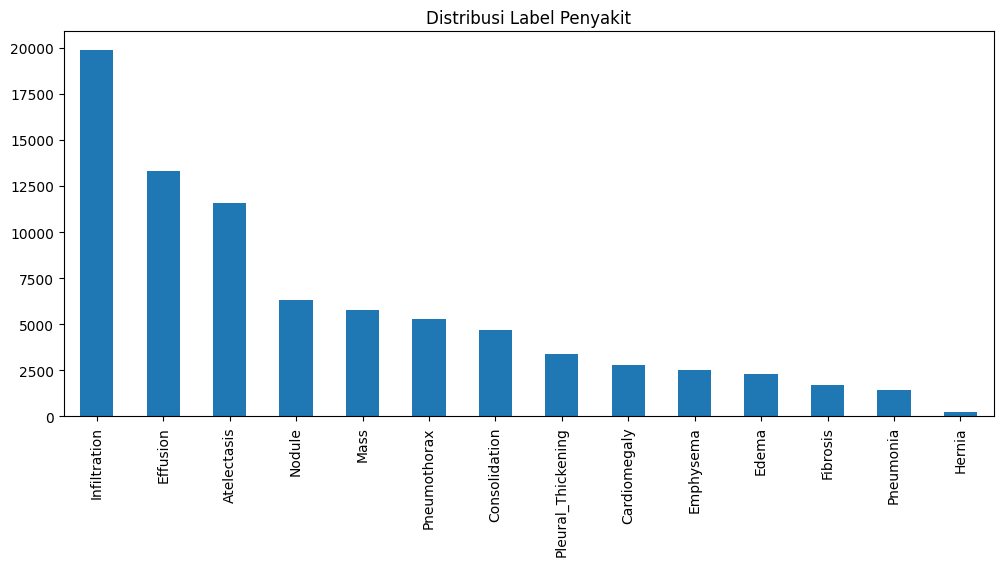

In [12]:
labelCounts.plot(kind="bar", figsize=(12, 5))
plt.title("Distribusi Label Penyakit")
plt.show()

# Training

## Split Data Patient-Wise

In [13]:
patientIds = masterDf["patientId"].dropna().unique()

trainPatients, tempPatients = train_test_split(
    patientIds,
    test_size=0.30,
    random_state=42
)

validPatients, testPatients = train_test_split(
    tempPatients,
    test_size=0.50,
    random_state=42
)

trainDf = masterDf[masterDf["patientId"].isin(trainPatients)].reset_index(drop=True)
validDf = masterDf[masterDf["patientId"].isin(validPatients)].reset_index(drop=True)
testDf = masterDf[masterDf["patientId"].isin(testPatients)].reset_index(drop=True)

print("Train shape:", trainDf.shape)
print("Valid shape:", validDf.shape)
print("Test shape:", testDf.shape)

Train shape: (78566, 28)
Valid shape: (17063, 28)
Test shape: (16491, 28)


## Prepare the TensorFlow Dataset

Use ACCELERATOR for GPU and CUDA access

In [14]:
imageSize = (224, 224)
batchSize = 32
autoTune = tf.data.AUTOTUNE

def decodeImage(imagePath):
    imageBytes = tf.io.read_file(imagePath)
    image = tf.io.decode_image(imageBytes, channels=1, expand_animations=False)
    image = tf.image.resize(image, imageSize)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.grayscale_to_rgb(image)
    image.set_shape([imageSize[0], imageSize[1], 3])
    return image

def makeDataset(dataDf, shuffle=True):
    xPaths = dataDf["imagePath"].values
    yLabels = dataDf[targetLabels].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((xPaths, yLabels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataDf), 10000), reshuffle_each_iteration=True)

    def mapFn(path, y):
        x = decodeImage(path)
        return x, y

    ds = ds.map(mapFn, num_parallel_calls=autoTune)
    ds = ds.batch(batchSize).prefetch(autoTune)
    return ds

trainDs = makeDataset(trainDf, shuffle=True)
validDs = makeDataset(validDf, shuffle=False)
testDs = makeDataset(testDf, shuffle=False)

print(trainDs)

I0000 00:00:1773735348.764750      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773735348.770829      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>


# Model Convolutional Neural Network (CNN)

In [15]:
numClasses = len(targetLabels)

cnnModel = keras.Sequential([
    layers.Input(shape=(imageSize[0], imageSize[1], 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(numClasses, activation="sigmoid")
])

cnnModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

cnnModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,870 (507.30 KB)

 Trainable params: 129,870 (507.30 KB)

 Non-trainable params: 0 (0.00 B)

## Training CNN

In [16]:
cnnCallbacks = [
    keras.callbacks.ModelCheckpoint("cnnBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
]

cnnHistory = cnnModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=cnnCallbacks
)

Epoch 1/10


I0000 00:00:1773735353.286987      68 service.cc:152] XLA service 0x79aae0107260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773735353.287026      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773735353.287032      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773735354.079803      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2456 ━━━━━━━━━━━━━━━━━━━━ 3:11 78ms/step - binaryAccuracy: 0.4727 - loss: 0.6978 - prAuc: 0.0360 - precision: 0.0407 - recall: 0.5063 - rocAuc: 0.4650  

I0000 00:00:1773735360.561451      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2456/2456 ━━━━━━━━━━━━━━━━━━━━ 659s 264ms/step - binaryAccuracy: 0.9480 - loss: 0.1922 - prAuc: 0.0990 - precision: 0.0563 - recall: 0.0049 - rocAuc: 0.6999 - val_binaryAccuracy: 0.9488 - val_loss: 0.1826 - val_prAuc: 0.1501 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7538 - learning_rate: 0.0010
Epoch 2/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 628s 256ms/step - binaryAccuracy: 0.9518 - loss: 0.1752 - prAuc: 0.1322 - precision: 0.0000e+00 - recall: 0.0000e+00 - rocAuc: 0.7401 - val_binaryAccuracy: 0.9488 - val_loss: 0.1792 - val_prAuc: 0.1593 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7615 - learning_rate: 0.0010
Epoch 3/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 609s 248ms/step - binaryAccuracy: 0.9519 - loss: 0.1736 - prAuc: 0.1405 - precision: 0.0000e+00 - recall: 0.0000e+00 - rocAuc: 0.7468 - val_binaryAccuracy: 0.9488 - val_loss: 0.1779 - val_prAuc: 0.1645 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7684 - learning_rate: 

## Evaluasi CNN

In [17]:
cnnEval = cnnModel.evaluate(testDs)
print(cnnEval)

516/516 ━━━━━━━━━━━━━━━━━━━━ 113s 218ms/step - binaryAccuracy: 0.9512 - loss: 0.1686 - prAuc: 0.1849 - precision: 0.2730 - recall: 2.0155e-04 - rocAuc: 0.7848
[0.17273157835006714, 0.9484909176826477, 0.7950295209884644, 0.19777846336364746, 0.4444444477558136, 0.00033638885361142457]


### Evaluation Metrics

In [18]:

evalMetrics = cnnModel.evaluate(validDs)

print(f'Loss: {evalMetrics[0]}')
print(f'Binary Accuracy: {evalMetrics[1]}')
print(f'ROC AUC: {evalMetrics[2]}')
print(f'PR AUC: {evalMetrics[3]}')
print(f'Precision: {evalMetrics[4]}')
print(f'Recall: {evalMetrics[5]}')

534/534 ━━━━━━━━━━━━━━━━━━━━ 78s 146ms/step - binaryAccuracy: 0.9530 - loss: 0.1643 - prAuc: 0.1874 - precision: 0.6693 - recall: 8.7584e-04 - rocAuc: 0.7849
Loss: 0.17067565023899078
Binary Accuracy: 0.9488571882247925
ROC AUC: 0.8013622164726257
PR AUC: 0.20711420476436615
Precision: 0.7333333492279053
Recall: 0.0008998691337183118


### Training and Validation Loss

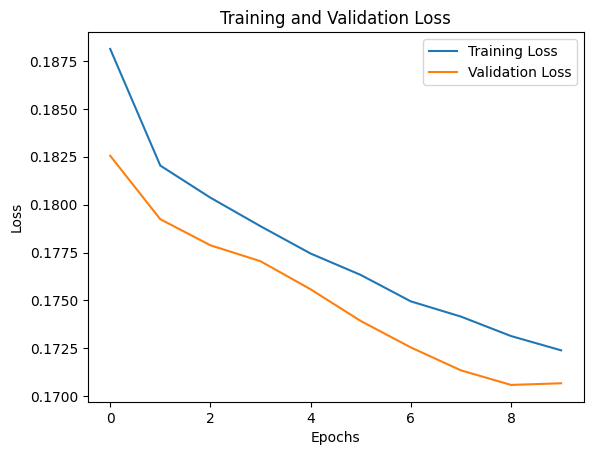

In [19]:
plt.plot(cnnHistory.history['loss'], label='Training Loss')
plt.plot(cnnHistory.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### Save Predictions & CNN Comparison

In [20]:
kaggleWorkingPath = Path("/kaggle/working")
outputRootPath = kaggleWorkingPath if kaggleWorkingPath.exists() else Path.cwd()
outputRootPath.mkdir(parents=True, exist_ok=True)

predictionOutputPath = outputRootPath / "prediction_comparison"
predictionOutputPath.mkdir(parents=True, exist_ok=True)

print(f"Prediction output folder: {predictionOutputPath}")


def buildComparisonDf(dataDf, trueArray, predProbArray, threshold=0.5):
    predArray = (predProbArray >= threshold).astype(int)

    def labelsToText(binaryRow):
        labels = [
            targetLabels[index]
            for index, flag in enumerate(binaryRow)
            if int(flag) == 1
        ]
        return " | ".join(labels) if labels else "No Finding"

    comparisonDf = pd.DataFrame({
        "imageIndex": dataDf["imageIndex"].values,
        "trueLabel": [labelsToText(row) for row in trueArray],
        "predictedLabel": [labelsToText(row) for row in predArray],
        "trueLabelCount": trueArray.sum(axis=1),
        "predictedLabelCount": predArray.sum(axis=1),
    })

    comparisonDf["exactMatch"] = (
        comparisonDf["trueLabel"] == comparisonDf["predictedLabel"]
    ).astype(int)

    return comparisonDf, predArray


def plotTrueVsPredLabelCounts(trueArray, predArray, modelName):
    trueCounts = trueArray.sum(axis=0)
    predCounts = predArray.sum(axis=0)

    plotDf = pd.DataFrame({
        "label": targetLabels,
        "actual": trueCounts,
        "predicted": predCounts,
    }).sort_values("actual", ascending=False)

    plt.figure(figsize=(14, 5))
    xPositions = np.arange(len(plotDf))
    width = 0.4

    plt.bar(xPositions - width / 2, plotDf["actual"], width=width, label="True Labels")
    plt.bar(xPositions + width / 2, plotDf["predicted"], width=width, label="Predicted Labels")

    plt.xticks(xPositions, plotDf["label"], rotation=60, ha="right")
    plt.title(f"Label Distribution Comparison - {modelName}")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

trueTestArray = testDf[targetLabels].values.astype(int)
cnnPredProb = cnnModel.predict(testDs, verbose=1)

cnnComparisonDf, cnnPredArray = buildComparisonDf(
    dataDf=testDf,
    trueArray=trueTestArray,
    predProbArray=cnnPredProb,
    threshold=0.5
)

cnnComparisonPath = predictionOutputPath / "cnn_label_comparison.csv"
cnnComparisonDf.to_csv(cnnComparisonPath, index=False)

print(f"CNN comparison file saved to: {cnnComparisonPath}")
print(f"Exact match ratio CNN: {cnnComparisonDf['exactMatch'].mean():.4f}")
cnnComparisonDf.head(10)

Prediction output folder: /kaggle/working/prediction_comparison
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 145ms/step
CNN comparison file saved to: /kaggle/working/prediction_comparison/cnn_label_comparison.csv
Exact match ratio CNN: 0.5402


,imageIndex,trueLabel,predictedLabel,trueLabelCount,predictedLabelCount,exactMatch
0,00000007_000.png,No Finding,No Finding,0,0,1
1,00000024_000.png,Fibrosis,No Finding,1,0,0
2,00000031_000.png,No Finding,No Finding,0,0,1
3,00000034_000.png,Emphysema,No Finding,1,0,0
4,00000034_001.png,No Finding,No Finding,0,0,1
5,00000035_000.png,No Finding,No Finding,0,0,1
6,00000035_001.png,No Finding,No Finding,0,0,1
7,00000036_000.png,Effusion | Infiltration,No Finding,2,0,0
8,00000042_000.png,No Finding,No Finding,0,0,1
9,00000042_001.png,No Finding,No Finding,0,0,1


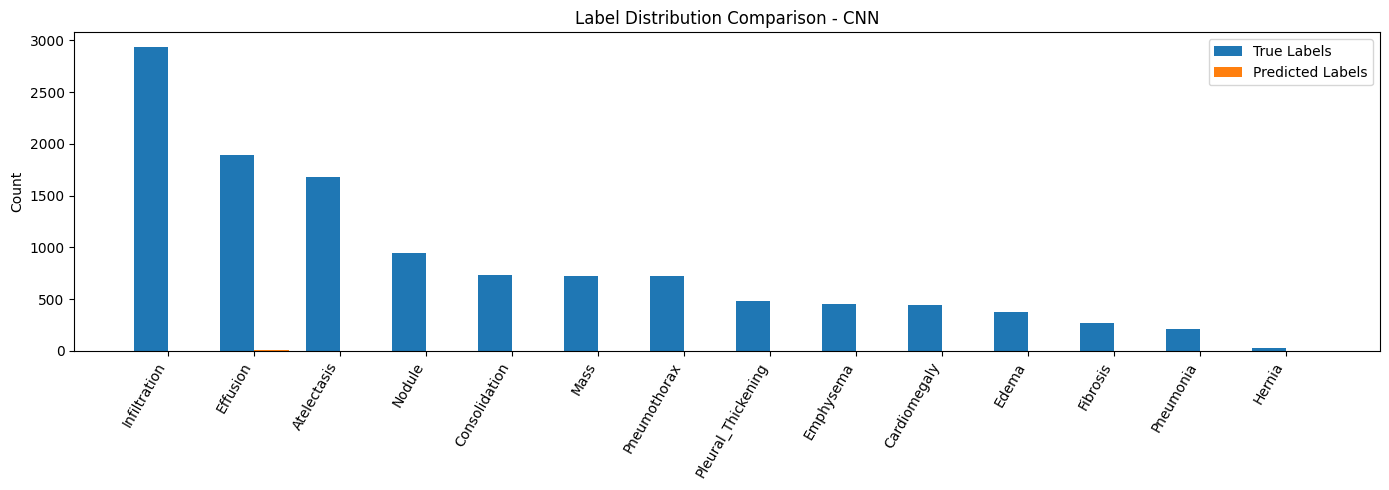

In [21]:
plotTrueVsPredLabelCounts(
    trueArray=trueTestArray,
    predArray=cnnPredArray,
    modelName="CNN"
)

# Model Residual Network (ResNet)

In [22]:
baseModel = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(imageSize[0], imageSize[1], 3)
)

baseModel.trainable = False

inputs = keras.Input(shape=(imageSize[0], imageSize[1], 3))
x = keras.applications.resnet.preprocess_input(inputs * 255.0)
x = baseModel(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(targetLabels), activation="sigmoid")(x)

resnetModel = keras.Model(inputs, outputs)

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetModel.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 14)        │     28,686 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## ResNet Training Stage 1

In [23]:
resnetCallbacks = [
    keras.callbacks.ModelCheckpoint("resnetFrozenBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=2, restore_best_weights=True)
]

resnetHistory1 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=5,
    callbacks=resnetCallbacks
)

Epoch 1/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 639s 255ms/step - binaryAccuracy: 0.9455 - loss: 0.1907 - prAuc: 0.1436 - precision: 0.2611 - recall: 0.0438 - rocAuc: 0.7462 - val_binaryAccuracy: 0.9485 - val_loss: 0.1718 - val_prAuc: 0.2162 - val_precision: 0.4605 - val_recall: 0.0367 - val_rocAuc: 0.8054
Epoch 2/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 846s 344ms/step - binaryAccuracy: 0.9504 - loss: 0.1677 - prAuc: 0.1904 - precision: 0.3768 - recall: 0.0420 - rocAuc: 0.7948 - val_binaryAccuracy: 0.9489 - val_loss: 0.1716 - val_prAuc: 0.2127 - val_precision: 0.5160 - val_recall: 0.0092 - val_rocAuc: 0.8106
Epoch 3/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 692s 282ms/step - binaryAccuracy: 0.9508 - loss: 0.1658 - prAuc: 0.1978 - precision: 0.4052 - recall: 0.0470 - rocAuc: 0.8008 - val_binaryAccuracy: 0.9488 - val_loss: 0.1677 - val_prAuc: 0.2200 - val_precision: 0.4900 - val_recall: 0.0200 - val_rocAuc: 0.8169
Epoch 4/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 663s 270ms/step - binaryAccuracy: 0.9504 - loss: 0.1663 

## Fine-Tuning ResNet

In [24]:
baseModel.trainable = True

for layer in baseModel.layers[:-30]:
    layer.trainable = False

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetHistory2 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint("resnetFineTuneBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
    ]
)

Epoch 1/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 729s 284ms/step - binaryAccuracy: 0.9496 - loss: 0.1709 - prAuc: 0.1895 - precision: 0.3625 - recall: 0.0567 - rocAuc: 0.7938 - val_binaryAccuracy: 0.9489 - val_loss: 0.1611 - val_prAuc: 0.2489 - val_precision: 0.5074 - val_recall: 0.0395 - val_rocAuc: 0.8369 - learning_rate: 1.0000e-05
Epoch 2/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 654s 266ms/step - binaryAccuracy: 0.9524 - loss: 0.1497 - prAuc: 0.2720 - precision: 0.5421 - recall: 0.0648 - rocAuc: 0.8483 - val_binaryAccuracy: 0.9488 - val_loss: 0.1598 - val_prAuc: 0.2560 - val_precision: 0.5009 - val_recall: 0.0441 - val_rocAuc: 0.8415 - learning_rate: 1.0000e-05
Epoch 3/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 654s 266ms/step - binaryAccuracy: 0.9530 - loss: 0.1406 - prAuc: 0.3308 - precision: 0.5933 - recall: 0.0951 - rocAuc: 0.8762 - val_binaryAccuracy: 0.9487 - val_loss: 0.1606 - val_prAuc: 0.2584 - val_precision: 0.4889 - val_recall: 0.0668 - val_rocAuc: 0.8408 - learning_rate: 1.0000e-05
Epoch 4/10

## Evaluasi ResNet

In [25]:
resnetEval = resnetModel.evaluate(testDs)
print(resnetEval)

516/516 ━━━━━━━━━━━━━━━━━━━━ 127s 247ms/step - binaryAccuracy: 0.9510 - loss: 0.1575 - prAuc: 0.2480 - precision: 0.4816 - recall: 0.0622 - rocAuc: 0.8325
[0.16170303523540497, 0.948664665222168, 0.8384124040603638, 0.2644541263580322, 0.5121799111366272, 0.06895972043275833]


### Training and Validation Loss

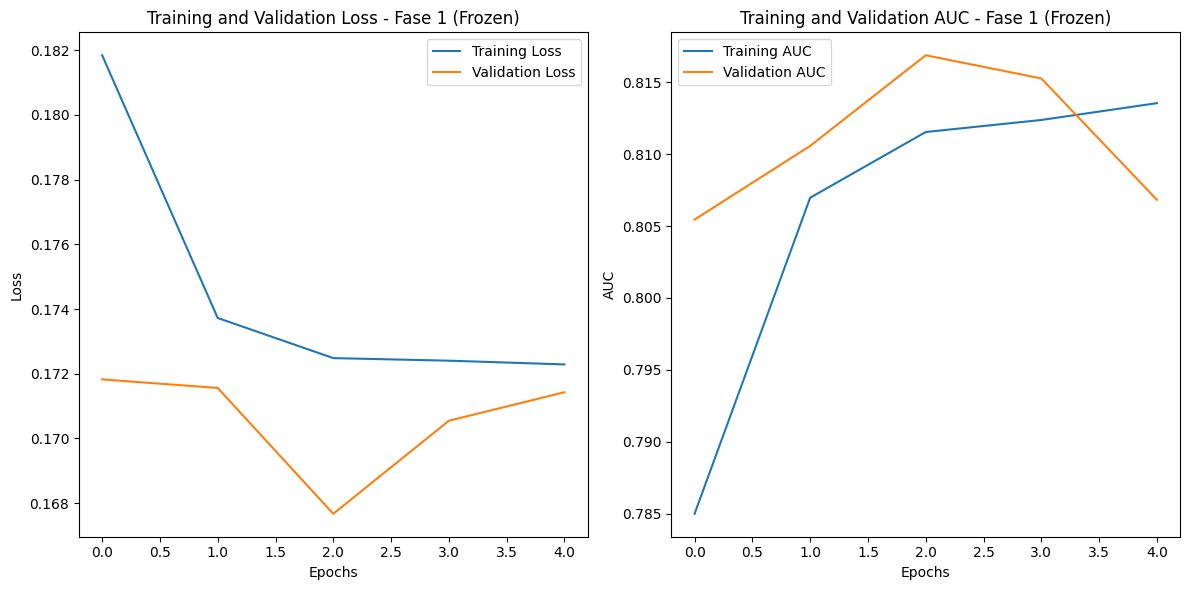

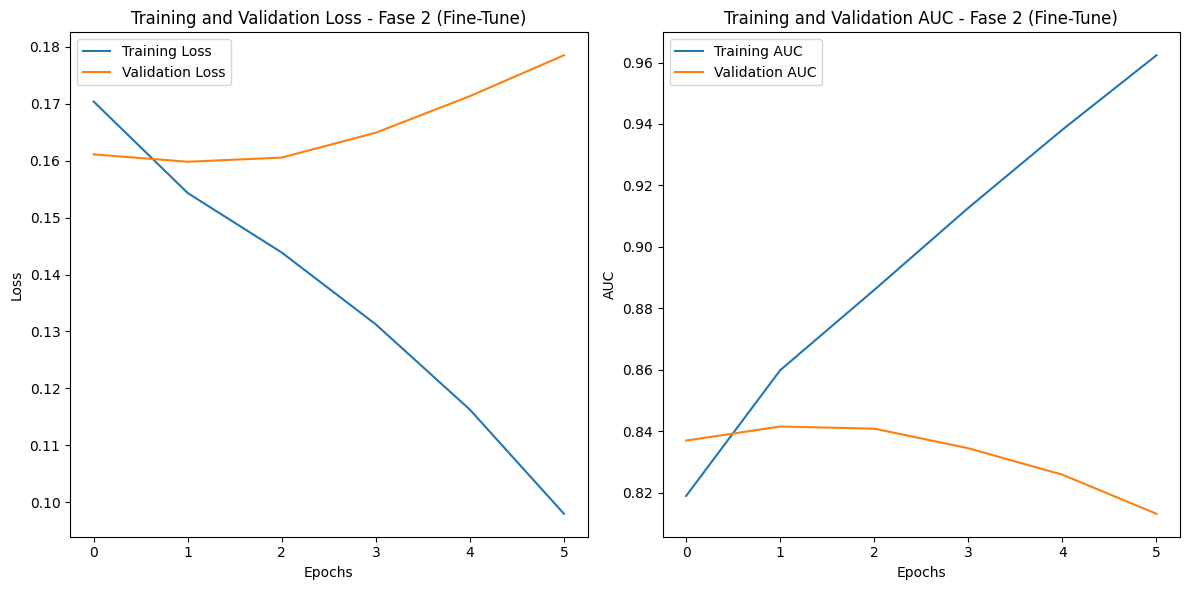

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(resnetHistory1.history['loss'], label='Training Loss')
plt.plot(resnetHistory1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Fase 1 (Frozen)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnetHistory1.history['rocAuc'], label='Training AUC')
plt.plot(resnetHistory1.history['val_rocAuc'], label='Validation AUC')
plt.title('Training and Validation AUC - Fase 1 (Frozen)')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(resnetHistory2.history['loss'], label='Training Loss')
plt.plot(resnetHistory2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Fase 2 (Fine-Tune)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnetHistory2.history['rocAuc'], label='Training AUC')
plt.plot(resnetHistory2.history['val_rocAuc'], label='Validation AUC')
plt.title('Training and Validation AUC - Fase 2 (Fine-Tune)')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

### Save Predictions & ResNet Comparison

In [27]:
resnetPredProb = resnetModel.predict(testDs, verbose=1)

resnetComparisonDf, resnetPredArray = buildComparisonDf(
    dataDf=testDf,
    trueArray=trueTestArray,
    predProbArray=resnetPredProb,
    threshold=0.5
)

resnetComparisonPath = predictionOutputPath / "resnet_label_comparison.csv"
resnetComparisonDf.to_csv(resnetComparisonPath, index=False)

print(f"ResNet comparison file saved to: {resnetComparisonPath}")
print(f"Exact match ratio ResNet: {resnetComparisonDf['exactMatch'].mean():.4f}")
resnetComparisonDf.head(10)

516/516 ━━━━━━━━━━━━━━━━━━━━ 103s 190ms/step
ResNet comparison file saved to: /kaggle/working/prediction_comparison/resnet_label_comparison.csv
Exact match ratio ResNet: 0.5379


,imageIndex,trueLabel,predictedLabel,trueLabelCount,predictedLabelCount,exactMatch
0,00000007_000.png,No Finding,No Finding,0,0,1
1,00000024_000.png,Fibrosis,No Finding,1,0,0
2,00000031_000.png,No Finding,No Finding,0,0,1
3,00000034_000.png,Emphysema,No Finding,1,0,0
4,00000034_001.png,No Finding,No Finding,0,0,1
5,00000035_000.png,No Finding,No Finding,0,0,1
6,00000035_001.png,No Finding,No Finding,0,0,1
7,00000036_000.png,Effusion | Infiltration,No Finding,2,0,0
8,00000042_000.png,No Finding,No Finding,0,0,1
9,00000042_001.png,No Finding,No Finding,0,0,1


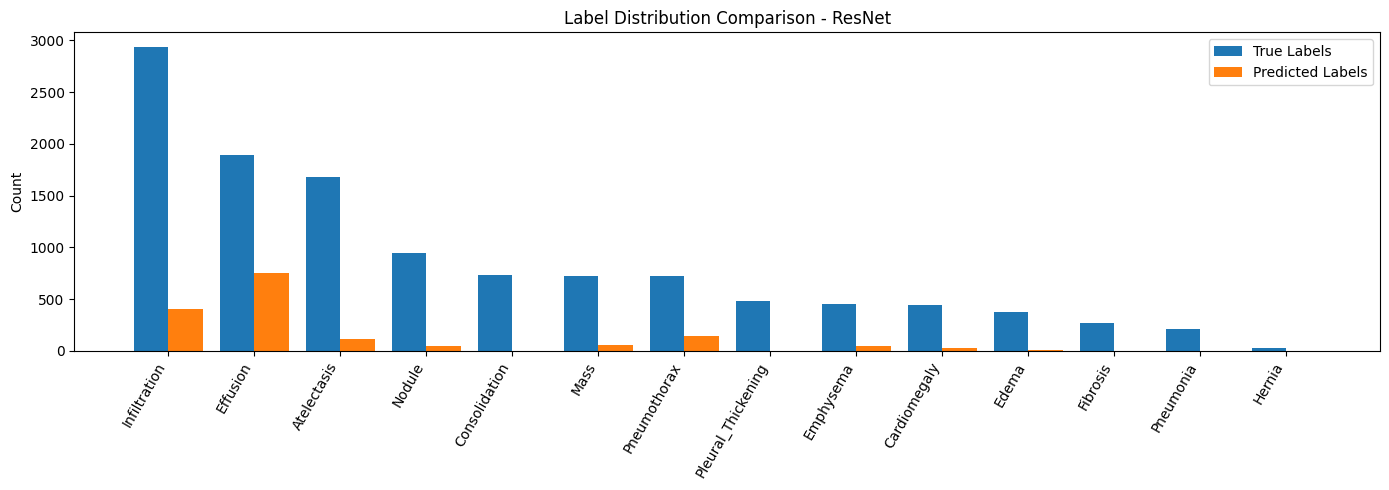

In [28]:
plotTrueVsPredLabelCounts(
    trueArray=trueTestArray,
    predArray=resnetPredArray,
    modelName="ResNet"
)

# CNN vs ResNet Comparison

In [29]:
requiredVars = [
    "cnnModel", "resnetModel", "trainDs", "validDs", "testDs",
    "cnnEval", "resnetEval", "cnnComparisonDf", "resnetComparisonDf"
]

missingVars = [varName for varName in requiredVars if varName not in globals()]
if missingVars:
    print("Variables not available yet:", missingVars)
    print("Run the CNN & ResNet training/evaluation cells first.")
else:
    print("All required variables are available. The notebook is ready to continue with the comparison.")

All required variables are available. The notebook is ready to continue with the comparison.


In [30]:
cnnMetricMap = dict(zip(cnnModel.metrics_names, cnnEval))
resnetMetricMap = dict(zip(resnetModel.metrics_names, resnetEval))

comparisonMetrics = ["loss", "binaryAccuracy", "rocAuc", "prAuc", "precision", "recall"]

modelComparisonRows = []
for metricName in comparisonMetrics:
    modelComparisonRows.append({
        "metric": metricName,
        "cnn": cnnMetricMap.get(metricName, np.nan),
        "resnet": resnetMetricMap.get(metricName, np.nan),
    })

modelComparisonDf = pd.DataFrame(modelComparisonRows)

exactMatchCnn = float(cnnComparisonDf["exactMatch"].mean())
exactMatchResnet = float(resnetComparisonDf["exactMatch"].mean())

exactMatchDf = pd.DataFrame([
    {"metric": "exactMatch", "cnn": exactMatchCnn, "resnet": exactMatchResnet}
])

modelComparisonWithExactDf = pd.concat([modelComparisonDf, exactMatchDf], ignore_index=True)

print("CNN vs ResNet metric comparison:")
display(modelComparisonWithExactDf.round(4))

CNN vs ResNet metric comparison:


,metric,cnn,resnet
0,loss,0.1727,0.1617
1,binaryAccuracy,NaN,NaN
2,rocAuc,NaN,NaN
3,prAuc,NaN,NaN
4,precision,NaN,NaN
5,recall,NaN,NaN
6,exactMatch,0.5402,0.5379


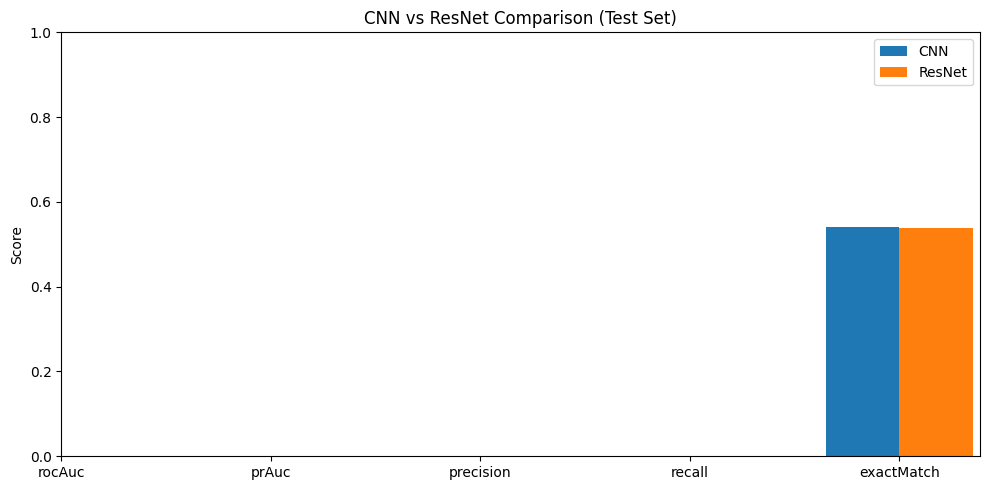

In [31]:
plotMetricsDf = modelComparisonWithExactDf[
    modelComparisonWithExactDf["metric"].isin(["rocAuc", "prAuc", "precision", "recall", "exactMatch"])
].copy()

xPositions = np.arange(len(plotMetricsDf))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(xPositions - width / 2, plotMetricsDf["cnn"], width=width, label="CNN")
plt.bar(xPositions + width / 2, plotMetricsDf["resnet"], width=width, label="ResNet")

plt.xticks(xPositions, plotMetricsDf["metric"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CNN vs ResNet Comparison (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## Comparison of Correct vs Incorrect Counts

Comparison of correct vs incorrect counts:


,model,correct,incorrect,correctRate,incorrectRate
0,CNN,8908,7583,0.540173,0.459827
1,ResNet,8870,7621,0.537869,0.462131


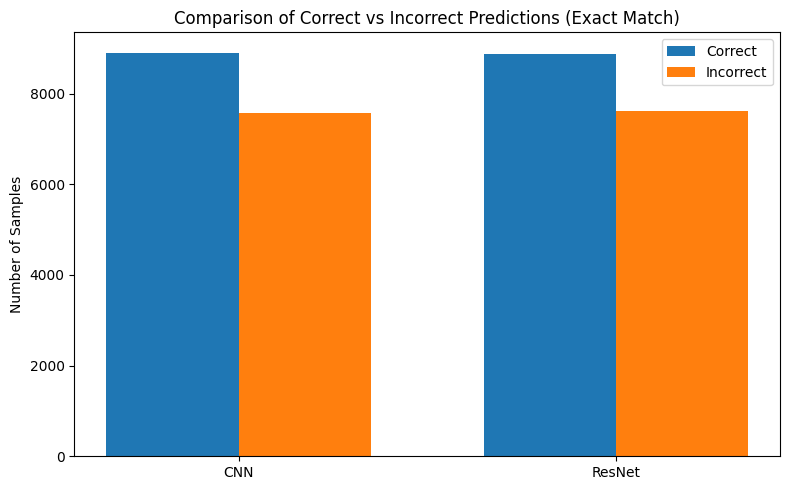

In [32]:
totalSamples = len(testDf)

cnnCorrect = int(cnnComparisonDf["exactMatch"].sum())
cnnWrong = int(totalSamples - cnnCorrect)

resnetCorrect = int(resnetComparisonDf["exactMatch"].sum())
resnetWrong = int(totalSamples - resnetCorrect)

correctWrongDf = pd.DataFrame([
    {
        "model": "CNN",
        "correct": cnnCorrect,
        "incorrect": cnnWrong,
        "correctRate": cnnCorrect / totalSamples,
        "incorrectRate": cnnWrong / totalSamples,
    },
    {
        "model": "ResNet",
        "correct": resnetCorrect,
        "incorrect": resnetWrong,
        "correctRate": resnetCorrect / totalSamples,
        "incorrectRate": resnetWrong / totalSamples,
    }
])

print("Comparison of correct vs incorrect counts:")
display(correctWrongDf)

xPositions = np.arange(len(correctWrongDf))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(xPositions - width / 2, correctWrongDf["correct"], width=width, label="Correct")
plt.bar(xPositions + width / 2, correctWrongDf["incorrect"], width=width, label="Incorrect")

plt.xticks(xPositions, correctWrongDf["model"])
plt.ylabel("Number of Samples")
plt.title("Comparison of Correct vs Incorrect Predictions (Exact Match)")
plt.legend()
plt.tight_layout()
plt.show()

# Model You Only Look Once (YOLO)

## Load Bounding Box

In [33]:
bboxDf = pd.read_csv(bboxPath)
bboxDf = bboxDf.iloc[:, :6].copy()
bboxDf.columns = ["imageIndex", "className", "x", "y", "w", "h"]

for columnName in ["x", "y", "w", "h"]:
    bboxDf[columnName] = pd.to_numeric(bboxDf[columnName], errors="coerce")

bboxDf.head()

,imageIndex,className,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


## Merge Bounding Box + Image Path + Patient

In [34]:
bboxMergedDf = bboxDf.merge(imagePathDf, on="imageIndex", how="left")
bboxMergedDf = bboxMergedDf.merge(
    labelDf[["imageIndex", "patientId", "originalImageWidth", "originalImageHeight"]],
    on="imageIndex",
    how="left"
)

bboxMergedDf = bboxMergedDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(bboxMergedDf.shape)
bboxMergedDf.head()

(984, 10)


,imageIndex,className,x,y,w,h,imagePath,patientId,originalImageWidth,originalImageHeight
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,/kaggle/input/datasets/organizations/nih-chest...,13118,2992,2991
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,/kaggle/input/datasets/organizations/nih-chest...,14716,3056,2544
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,/kaggle/input/datasets/organizations/nih-chest...,29817,3056,2544
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,/kaggle/input/datasets/organizations/nih-chest...,14687,2500,2048
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,/kaggle/input/datasets/organizations/nih-chest...,17877,2500,2048


## Split YOLO Data

In [35]:
bboxPatientIds = bboxMergedDf["patientId"].dropna().unique()

trainPatientsYolo, tempPatientsYolo = train_test_split(
    bboxPatientIds,
    test_size=0.30,
    random_state=42
)

validPatientsYolo, testPatientsYolo = train_test_split(
    tempPatientsYolo,
    test_size=0.50,
    random_state=42
)

trainBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(trainPatientsYolo)].reset_index(drop=True)
validBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(validPatientsYolo)].reset_index(drop=True)
testBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(testPatientsYolo)].reset_index(drop=True)

print(trainBboxDf.shape, validBboxDf.shape, testBboxDf.shape)

(684, 10) (160, 10) (140, 10)


## Mapping Class YOLO

In [36]:
classNames = sorted(bboxMergedDf["className"].dropna().unique().tolist())
classToId = {name: index for index, name in enumerate(classNames)}

print(classToId)

{'Atelectasis': 0, 'Cardiomegaly': 1, 'Effusion': 2, 'Infiltrate': 3, 'Mass': 4, 'Nodule': 5, 'Pneumonia': 6, 'Pneumothorax': 7}


## Create YOLO Folder

In [37]:
yoloRootPath = Path("/kaggle/working/nihYOLO")

for splitName in ["train", "val", "test"]:
    (yoloRootPath / "images" / splitName).mkdir(parents=True, exist_ok=True)
    (yoloRootPath / "labels" / splitName).mkdir(parents=True, exist_ok=True)

## Konversi ke Format YOLO

In [38]:
def writeYoloSplit(splitDf, splitName):
    groupedDf = splitDf.groupby("imageIndex")

    for imageIndex, groupDf in groupedDf:
        imagePath = groupDf["imagePath"].iloc[0]
        imageWidth = float(groupDf["originalImageWidth"].iloc[0])
        imageHeight = float(groupDf["originalImageHeight"].iloc[0])

        outputImagePath = yoloRootPath / "images" / splitName / imageIndex
        outputLabelPath = yoloRootPath / "labels" / splitName / (Path(imageIndex).stem + ".txt")

        shutil.copy(imagePath, outputImagePath)

        yoloLines = []
        for _, row in groupDf.iterrows():
            classId = classToId[row["className"]]

            x = float(row["x"])
            y = float(row["y"])
            w = float(row["w"])
            h = float(row["h"])

            xCenter = (x + w / 2.0) / imageWidth
            yCenter = (y + h / 2.0) / imageHeight
            widthNorm = w / imageWidth
            heightNorm = h / imageHeight

            yoloLines.append(
                f"{classId} {xCenter:.6f} {yCenter:.6f} {widthNorm:.6f} {heightNorm:.6f}"
            )

        outputLabelPath.write_text("\n".join(yoloLines))

writeYoloSplit(trainBboxDf, "train")
writeYoloSplit(validBboxDf, "val")
writeYoloSplit(testBboxDf, "test")

## Create data.yaml

In [39]:
dataYamlPath = yoloRootPath / "data.yaml"

yamlText = f"""path: {str(yoloRootPath)}
train: images/train
val: images/val
test: images/test

names:
"""

for index, className in enumerate(classNames):
    yamlText += f"  {index}: {className}\n"

dataYamlPath.write_text(yamlText)
print(yamlText)

path: /kaggle/working/nihYOLO
train: images/train
val: images/val
test: images/test

names:
  0: Atelectasis
  1: Cardiomegaly
  2: Effusion
  3: Infiltrate
  4: Mass
  5: Nodule
  6: Pneumonia
  7: Pneumothorax



## Install dan Train YOLO

In [40]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00


In [41]:
%%capture --no-stdout --no-display
from ultralytics import YOLO

yoloModel = YOLO("yolov8n.pt")

yoloModel.train(
    data=str(dataYamlPath),
    imgsz=640,
    epochs=50,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/nihYOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79a75478e660>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

## Evaluasi YOLO

In [42]:
import json

yoloMetrics = yoloModel.val(data=str(dataYamlPath), verbose=False)

outputBasePath = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
yoloEvalPath = outputBasePath / "yolo_evaluation"
yoloEvalPath.mkdir(parents=True, exist_ok=True)

jsonPath = yoloEvalPath / "yolo_metrics.json"
csvPath = yoloEvalPath / "yolo_metrics.csv"
rawTextPath = yoloEvalPath / "yolo_metrics_raw.txt"

rawTextPath.write_text(str(yoloMetrics))

if hasattr(yoloMetrics, "results_dict"):
    metricDict = {
        key: float(value) if isinstance(value, (int, float, np.integer, np.floating)) else str(value)
        for key, value in yoloMetrics.results_dict.items()
    }
else:
    metricDict = {"message": "results_dict is not available", "raw_repr": str(yoloMetrics)}

jsonPath.write_text(json.dumps(metricDict, indent=2))
pd.DataFrame([metricDict]).to_csv(csvPath, index=False)

print(f"YOLO metrics saved to: {jsonPath}")
print(f"CSV summary saved to: {csvPath}")
print(f"Raw evaluation results saved to: {rawTextPath}")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3542.6±1099.1 MB/s, size: 417.9 KB)
val: Scanning /kaggle/working/nihYOLO/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 40.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.6it/s 3.5s
                   all        143        160      0.757     0.0272    0.00754     0.0028
Speed: 6.1ms preprocess, 4.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
YOLO metrics saved to: /kaggle/working/yolo_evaluation/yolo_metrics.json
CSV summary saved to: /kaggle/working/yolo_evaluation/yolo_metrics.csv
Raw evaluation results saved to: /kaggle/working/yolo_evaluation/yolo_metrics_raw.txt


### Save YOLO Model

In [43]:
yoloModel.save("/kaggle/working/YOLOTrainedModel.pt")
print("The YOLO model has been saved.")

The YOLO model has been saved.
